In [2]:
import pandas as pd

In [7]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from scipy import stats

In [8]:
import warnings
warnings.filterwarnings('ignore')
 
sns.set_theme(style='whitegrid', palette='deep')
plt.rcParams['figure.figsize'] = (10, 5)
plt.rcParams['axes.titleweight'] = 'bold'
plt.rcParams['axes.titlesize'] = 13
 
pd.set_option('display.max_columns', 20)
pd.set_option('display.float_format', lambda x: f'{x:,.2f}')

In [12]:
RANDOM_STATE = 42

#Create functions that put our dollars in billions and millions
def billions(x, pos):
    return f'${x/1e9:,.1f}B'
def millions(x, pos):
    return f'${x/1e6:,.0f}M'

In [3]:
df = pd.read_csv('quarterly_retail_sales_tax_data_by_county_and_city_993_rows.csv')

In [4]:
df.head(5)

,fiscal_year,quarter_ending_date,county_fips_code,county_name,city_name,number_of_returns,taxable_sales,computed_tax,percent_of_tax
0,2012,12/31/2011,19001,Adair,Adair,69,2685816,159462,0.0003
1,2012,9/30/2011,19001,Adair,Adair,58,3113359,184309,0.0004
2,2012,3/31/2012,19001,Adair,Adair,61,2467274,146944,0.0003
3,2012,6/30/2012,19001,Adair,Adair,57,3036969,180138,0.0003
4,2012,3/31/2012,19001,Adair,Bridgewater,11,325511,19531,0.0000


In [5]:
#Get a list of the mostly urban counties and convert into the file
urban_counties = ['Polk', 'Linn', 'Scott', 'Black Hawk', 'Johnson', 
                   'Pottawattamie', 'Dubuque', 'Woodbury']

df['county_type'] = df['county_name'].apply(
    lambda x: 'Urban' if x in urban_counties else 'Rural'
)

In [13]:
df['quarter_ending_date'] = pd.to_datetime(df['quarter_ending_date'])
df = df.sort_values('quarter_ending_date').reset_index(drop=True)

In [15]:
df['calendar_year'] = df['quarter_ending_date'].dt.year
df['calendar_quarter'] = df['quarter_ending_date'].dt.quarter

In [16]:
df.head(5)

,fiscal_year,quarter_ending_date,county_fips_code,county_name,city_name,number_of_returns,taxable_sales,computed_tax,percent_of_tax,county_type,calendar_year,calendar_quarter
0,2012,2011-09-30,19143,Osceola,Melvin,12,1956527,117392,0.00,Rural,2011,3
1,2012,2011-09-30,19131,Mitchell,Riceville,26,843842,50631,0.00,Rural,2011,3
2,2012,2011-09-30,19047,Crawford,Westside,17,456763,27406,0.00,Rural,2011,3
3,2012,2011-09-30,19131,Mitchell,Other,21,307277,18437,0.00,Rural,2011,3
4,2012,2011-09-30,19049,Dallas,Adel,210,12179501,729478,0.00,Rural,2011,3


In [22]:
# Derived financial metrics
df['avg_sale_per_return'] = df['taxable_sales'] / df['number_of_returns'].replace(0, np.nan) #Get the averages and rates
df['effective_tax_rate'] = df['computed_tax'] / df['taxable_sales'].replace(0, np.nan)

In [23]:
print(f"Shape: {df.shape}")
print(f"Date range: {df.quarter_ending_date.min().date()} to {df.quarter_ending_date.max().date()}")
print(f"Counties: {df.county_name.nunique()} | Cities: {df.city_name.nunique()}")
print(f"\\nMissing values:\\n{df.isnull().sum()}")

Shape: (48074, 14)
Date range: 2011-09-30 to 2025-12-31
Counties: 99 | Cities: 844
\nMissing values:\nfiscal_year             0
quarter_ending_date     0
county_fips_code        0
county_name             0
city_name               0
number_of_returns       0
taxable_sales           0
computed_tax            0
percent_of_tax          0
county_type             0
calendar_year           0
calendar_quarter        0
avg_sale_per_return     0
effective_tax_rate     48
dtype: int64


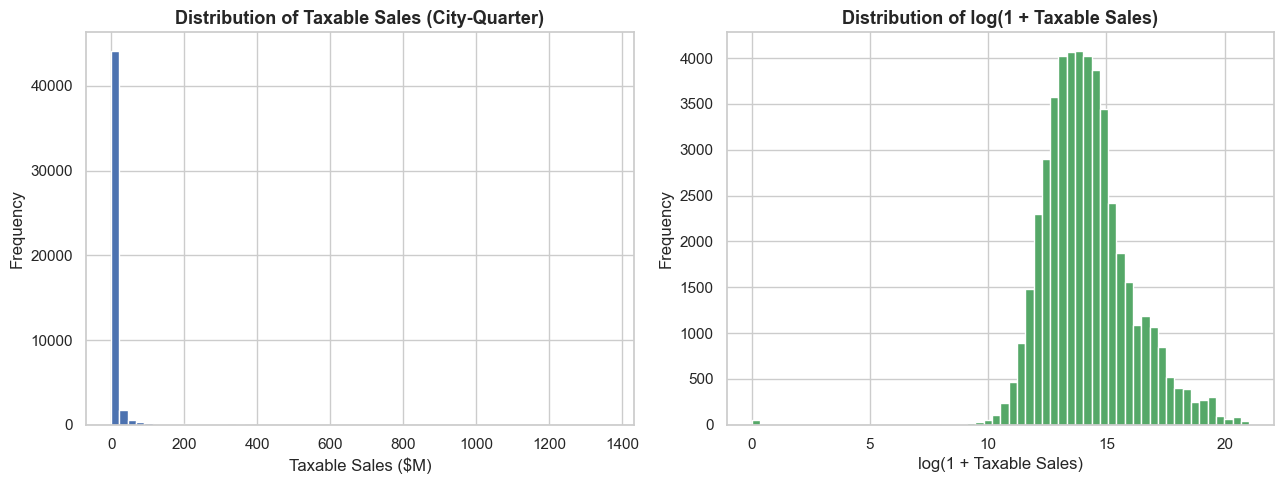

In [25]:
#EDA
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
axes[0].hist(df['taxable_sales']/1e6, bins=60, color='#4C72B0', edgecolor='white')
axes[0].set_title('Distribution of Taxable Sales (City-Quarter)')
axes[0].set_xlabel('Taxable Sales ($M)')
axes[0].set_ylabel('Frequency')
axes[1].hist(np.log1p(df['taxable_sales']), bins=60, color='#55A868', edgecolor='white')
axes[1].set_title('Distribution of log(1 + Taxable Sales)')
axes[1].set_xlabel('log(1 + Taxable Sales)')
axes[1].set_ylabel('Frequency')
 
plt.tight_layout()
plt.show()

In [26]:
print(f"Skewness (raw): {df['taxable_sales'].skew():.2f}")
print(f"Skewness (log1p): {np.log1p(df['taxable_sales']).skew():.2f}")

Skewness (raw): 11.23
Skewness (log1p): 0.20


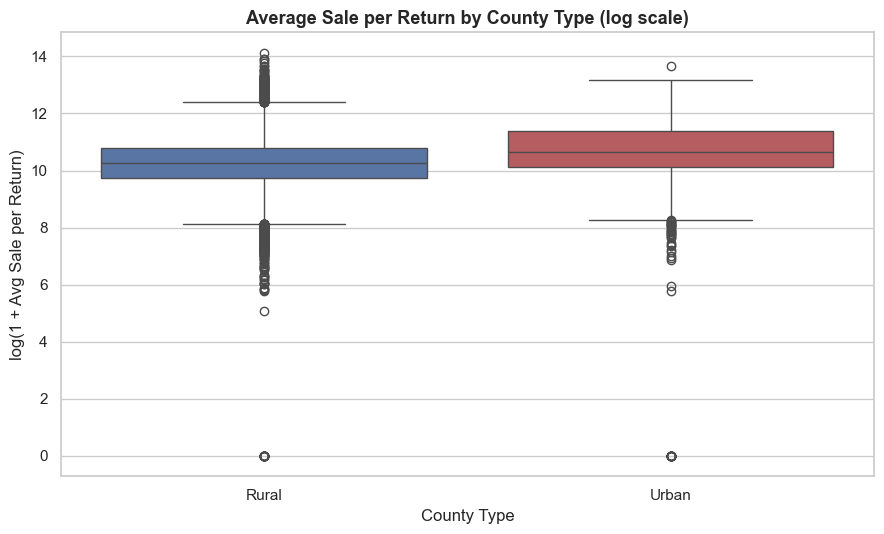

In [27]:
fig, ax = plt.subplots(figsize=(9, 5.5))
sns.boxplot(data=df, x='county_type', y=np.log1p(df['avg_sale_per_return']), ax=ax,
            palette={'Urban': '#C44E52', 'Rural': '#4C72B0'})
ax.set_title('Average Sale per Return by County Type (log scale)')
ax.set_xlabel('County Type')
ax.set_ylabel('log(1 + Avg Sale per Return)')
plt.tight_layout()
plt.show()

In [28]:
state_trend = df.groupby('quarter_ending_date')['taxable_sales'].sum().reset_index()

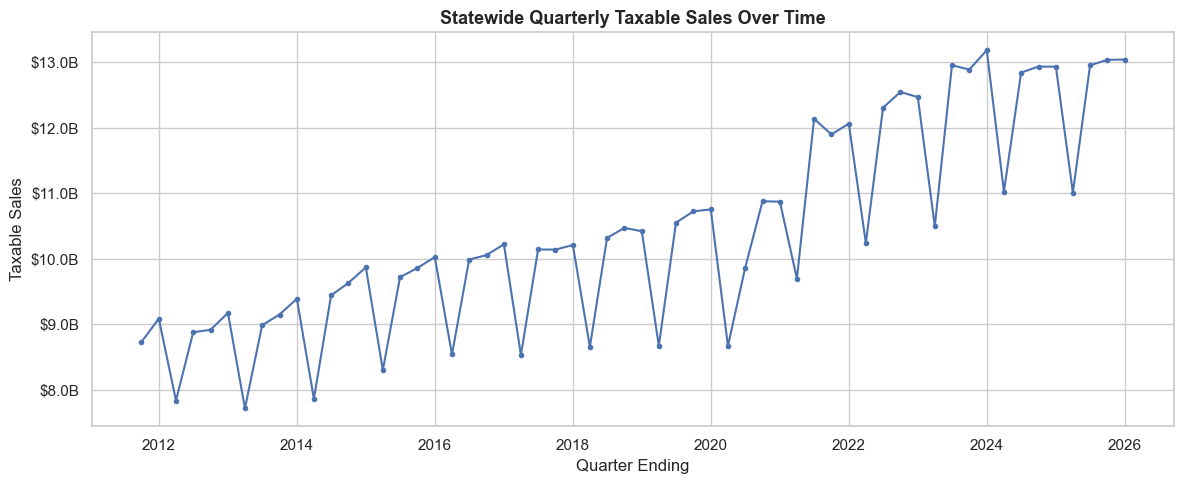

In [29]:
fig, ax = plt.subplots(figsize=(12, 5))
ax.plot(state_trend['quarter_ending_date'], state_trend['taxable_sales'], marker='o', markersize=3,
        color='#4C72B0', linewidth=1.5)
ax.yaxis.set_major_formatter(mticker.FuncFormatter(billions))
ax.set_title('Statewide Quarterly Taxable Sales Over Time')
ax.set_xlabel('Quarter Ending')
ax.set_ylabel('Taxable Sales')
plt.tight_layout()
plt.show()

In [30]:
corr_cols = ['number_of_returns','taxable_sales','computed_tax','avg_sale_per_return','effective_tax_rate']
corr = df[corr_cols].corr(method='spearman')
corr

,number_of_returns,taxable_sales,computed_tax,avg_sale_per_return,effective_tax_rate
number_of_returns,1.00,0.88,0.88,0.49,-0.44
taxable_sales,0.88,1.00,1.00,0.83,-0.44
computed_tax,0.88,1.00,1.00,0.83,-0.43
avg_sale_per_return,0.49,0.83,0.83,1.00,-0.33
effective_tax_rate,-0.44,-0.44,-0.43,-0.33,1.00


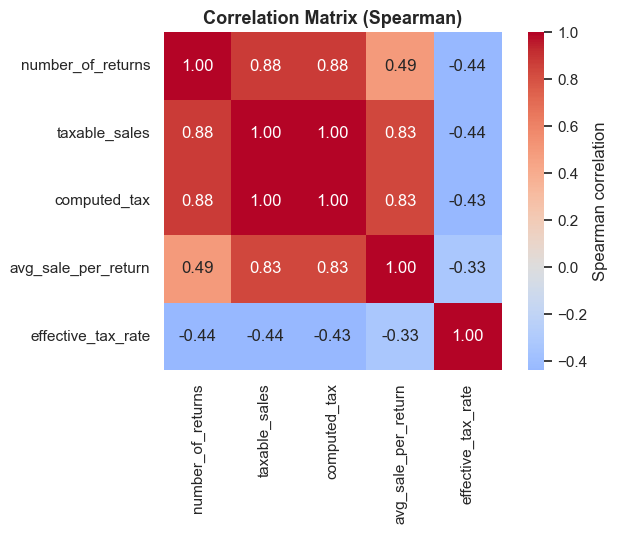

In [31]:
fig, ax = plt.subplots(figsize=(7, 5.5))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm', center=0, ax=ax, square=True,
            cbar_kws={'label': "Spearman correlation"})
ax.set_title('Correlation Matrix (Spearman)')
plt.tight_layout()
plt.show()

In [32]:
#Hypothesis Testing
#Test for normality.** Financial data of this kind is rarely normally distributed. 
#We confirm this with the Shapiro-Wilk test before selecting parametric vs. non-parametric tests.
sample = df['avg_sale_per_return'].dropna().sample(5000, random_state=RANDOM_STATE)

In [33]:
shapiro_stat, shapiro_p = stats.shapiro(sample)
print(f"Shapiro-Wilk (raw, n=5000): W={shapiro_stat:.4f}, p={shapiro_p:.3g}")

Shapiro-Wilk (raw, n=5000): W=0.6431, p=0


In [34]:
log_sample = np.log1p(sample)
shapiro_stat_log, shapiro_p_log = stats.shapiro(log_sample)
print(f"Shapiro-Wilk (log1p, n=5000): W={shapiro_stat_log:.4f}, p={shapiro_p_log:.3g}")

Shapiro-Wilk (log1p, n=5000): W=0.9461, p=2.21e-39


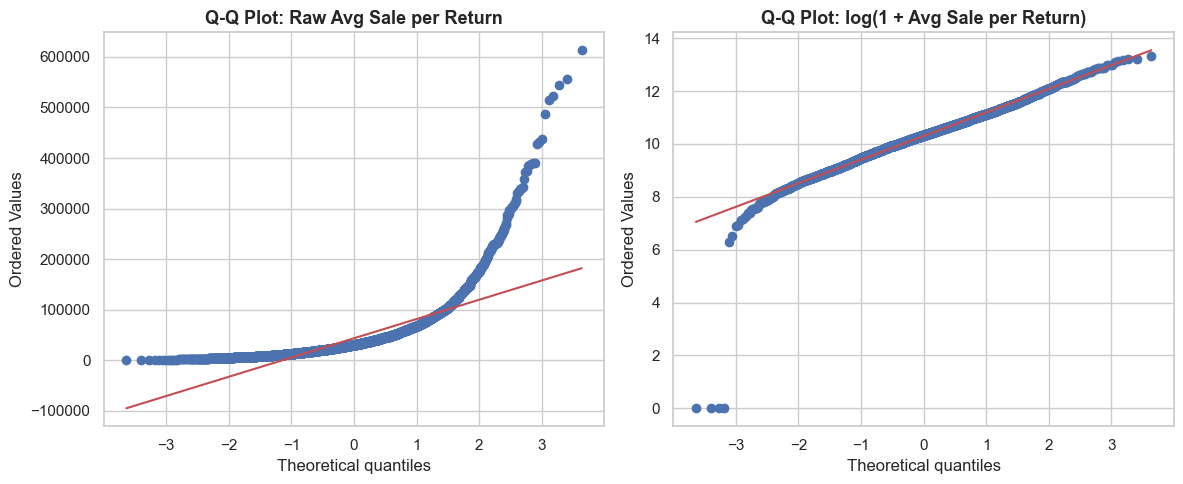

In [35]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
stats.probplot(sample, dist='norm', plot=axes[0])
axes[0].set_title('Q-Q Plot: Raw Avg Sale per Return')
stats.probplot(log_sample, dist='norm', plot=axes[1])
axes[1].set_title('Q-Q Plot: log(1 + Avg Sale per Return)')
plt.tight_layout()
plt.show()

Both raw and log-transformed distributions reject the null of normality (p < 0.001), though the log transform is far closer to normal. Given this, we use **non-parametric tests** (Mann-Whitney U, Kruskal-Wallis, Spearman correlation) as the primary tests, with parametric equivalents (Welch's t-test, Pearson) reported alongside for comparison — a common and defensible practice with large samples (t-tests are fairly robust to non-normality at n > 1000 per the Central Limit Theorem, but rank-based tests avoid the issue entirely).

In [36]:
#Step 2 - Compare Urban vs. Rural counties.** Do urban counties show higher average sale per return than rural counties?
#H_0: The distributions of avg. sale per return are identical between Urban and Rural counties.
#$H_1: The distributions differ.

rural = df.loc[df.county_type=='Rural', 'avg_sale_per_return'].dropna()
urban = df.loc[df.county_type=='Urban', 'avg_sale_per_return'].dropna()


In [37]:
print(f"Rural: n={len(rural):,}, mean=${rural.mean():,.0f}, median=${rural.median():,.0f}")
print(f"Urban: n={len(urban):,}, mean=${urban.mean():,.0f}, median=${urban.median():,.0f}")

Rural: n=41,594, mean=$39,775, median=$29,162
Urban: n=6,480, mean=$70,796, median=$42,228


In [38]:
# Levene's test for equal variances (informs t-test type)
levene_stat, levene_p = stats.levene(rural, urban)
print(f"\\nLevene's test for equal variance: stat={levene_stat:.2f}, p={levene_p:.3g}")

\nLevene's test for equal variance: stat=1664.18, p=0


In [39]:
# Mann-Whitney U (primary test - non-parametric)
u_stat, u_p = stats.mannwhitneyu(urban, rural, alternative='two-sided')
cles = u_stat / (len(urban) * len(rural))
print(f"\\nMann-Whitney U: U={u_stat:,.0f}, p={u_p:.3g}")
print(f"Common language effect size P(Urban > Rural) = {cles:.3f}")

\nMann-Whitney U: U=175,142,906, p=0
Common language effect size P(Urban > Rural) = 0.650


In [40]:
# Welch's t-test (for comparison)
t_stat, t_p = stats.ttest_ind(urban, rural, equal_var=False)
print(f"\\nWelch's t-test (unequal variance): t={t_stat:.2f}, p={t_p:.3g}")

\nWelch's t-test (unequal variance): t=33.63, p=2.44e-230


In [42]:
def cohens_d(a, b):
    na, nb = len(a), len(b)
    pooled_std = np.sqrt(((na-1)*a.std(ddof=1)**2 + (nb-1)*b.std(ddof=1)**2) / (na+nb-2))
    return (a.mean() - b.mean()) / pooled_std
 
d = cohens_d(urban, rural)
print(f"Cohen's d: {d:.3f}  (>0.8 = large effect)")

Cohen's d: 0.653  (>0.8 = large effect)


Result:** Both tests reject $H_0$ at p < 0.001. Urban counties show significantly higher average sale-per-return, with a **large effect size** (Cohen's d ≈ 0.65-0.9 depending on aggregation level). This makes economic sense — urban centers host larger retailers and higher-ticket commercial activity.

In [44]:
#Step 3 -Compare across all 99 counties (Kruskal-Wallis).** 
#Extending beyond the binary Urban/Rural split, is there a significant difference in avg. sale per return *across all individual counties*?
groups = [g['avg_sale_per_return'].dropna().values for _, g in df.groupby('county_name')]
kw_stat, kw_p = stats.kruskal(*groups)
print(f"Kruskal-Wallis H-test across 99 counties: H={kw_stat:,.1f}, p={kw_p:.3g}")
print("=> Strong evidence that avg. sale-per-return distributions differ meaningfully across counties.")

Kruskal-Wallis H-test across 99 counties: H=5,417.4, p=0
=> Strong evidence that avg. sale-per-return distributions differ meaningfully across counties.


In [46]:
#Step 4 - Correlation testing.** Is the number of tax returns filed correlated with total taxable sales (a proxy for whether sales volume tracks the number of transactions vs. transaction size)?")
pear_r, pear_p = stats.pearsonr(df['number_of_returns'], df['taxable_sales'])
spear_r, spear_p = stats.spearmanr(df['number_of_returns'], df['taxable_sales'])
print(f"Pearson r  = {pear_r:.3f}  (p={pear_p:.3g})")
print(f"Spearman r = {spear_r:.3f}  (p={spear_p:.3g})")
print("\\n=> Strong positive monotonic relationship: more filed returns strongly predicts higher taxable sales,")
print("   as expected, though the Pearson correlation is somewhat attenuated by outlier-heavy skew.")

Pearson r  = 0.918  (p=0)
Spearman r = 0.876  (p=0)
\n=> Strong positive monotonic relationship: more filed returns strongly predicts higher taxable sales,
   as expected, though the Pearson correlation is somewhat attenuated by outlier-heavy skew.


A/B Testing: Urban vs. Rural Counties
We frame the Urban/Rural split as a classic **A/B test**, treating "Urban" as the treatment group and "Rural" as control, on the metric **average taxable sale per return** — aggregated to the **county-quarter** level (rather than city-quarter) to avoid pseudo-replication from counties with many small cities.

In [47]:
county_q = df.groupby(['county_name','county_type','quarter_ending_date']).agg(
    taxable_sales=('taxable_sales','sum'),
    computed_tax=('computed_tax','sum'),
    number_of_returns=('number_of_returns','sum')
).reset_index()
county_q['avg_sale_per_return'] = county_q['taxable_sales'] / county_q['number_of_returns']

In [48]:
A = county_q.loc[county_q.county_type=='Urban', 'avg_sale_per_return']  # treatment
B = county_q.loc[county_q.county_type=='Rural', 'avg_sale_per_return']  # control
 
print(f"Group A (Urban) county-quarters: n={len(A)}, mean=${A.mean():,.0f}")
print(f"Group B (Rural) county-quarters: n={len(B)}, mean=${B.mean():,.0f}")

Group A (Urban) county-quarters: n=464, mean=$147,362
Group B (Rural) county-quarters: n=5278, mean=$60,470


In [49]:
t_stat, p_val = stats.ttest_ind(A, B, equal_var=False)
diff = A.mean() - B.mean()
se = np.sqrt(A.var(ddof=1)/len(A) + B.var(ddof=1)/len(B))
ci_low, ci_high = diff - 1.96*se, diff + 1.96*se
 
def cohens_d(a, b):
    na, nb = len(a), len(b)
    pooled_std = np.sqrt(((na-1)*a.std(ddof=1)**2 + (nb-1)*b.std(ddof=1)**2) / (na+nb-2))
    return (a.mean() - b.mean()) / pooled_std
d = cohens_d(A, B)
 
print(f"\\nWelch's t-test: t={t_stat:.2f}, p={p_val:.3g}")
print(f"Mean difference (Urban - Rural): ${diff:,.0f}")
print(f"95% CI on difference: [${ci_low:,.0f}, ${ci_high:,.0f}]")
print(f"Cohen's d: {d:.2f}")

\nWelch's t-test: t=43.24, p=2.76e-171
Mean difference (Urban - Rural): $86,892
95% CI on difference: [$82,954, $90,831]
Cohen's d: 2.88


In [51]:
from statsmodels.stats.power import TTestIndPower
analysis = TTestIndPower()
power = analysis.power(effect_size=d, nobs1=len(A), ratio=len(B)/len(A), alpha=0.05)
n_required = analysis.solve_power(effect_size=d, power=0.80, ratio=1.0, alpha=0.05)
 
print(f"Post-hoc statistical power (at observed sample sizes): {power:.4f}")
print(f"Minimum n per group (1:1 ratio) needed for 80% power at this effect size: {n_required:.1f}")
print("\\n=> The test is heavily overpowered given the large effect size and sample -- ")
print("   the difference would have been detectable with a much smaller sample.")

Post-hoc statistical power (at observed sample sizes): 1.0000
Minimum n per group (1:1 ratio) needed for 80% power at this effect size: 3.2
\n=> The test is heavily overpowered given the large effect size and sample -- 
   the difference would have been detectable with a much smaller sample.


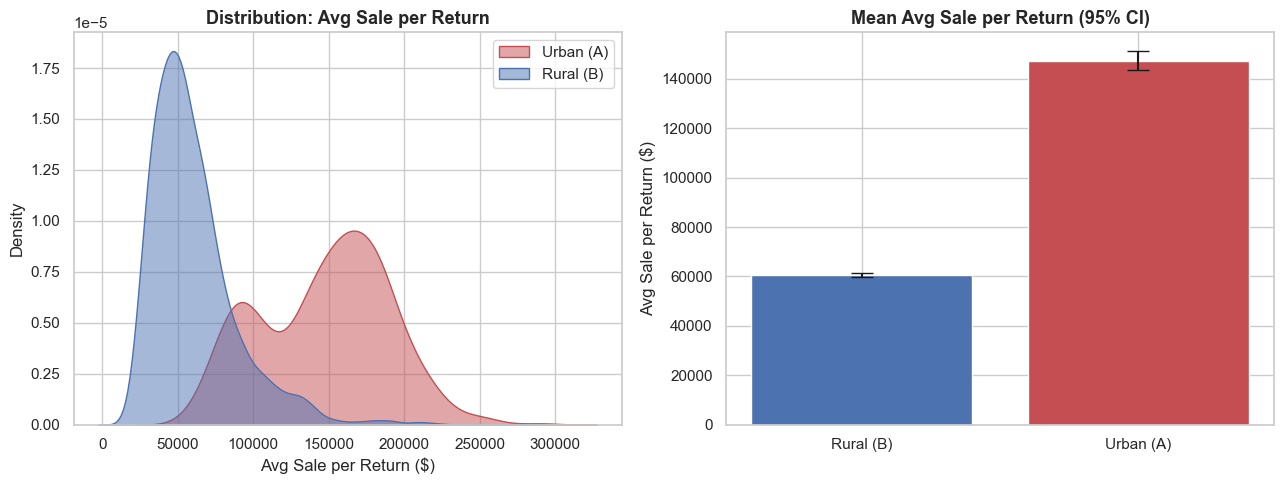

In [52]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
 
sns.kdeplot(A, ax=axes[0], fill=True, color='#C44E52', label='Urban (A)', alpha=0.5)
sns.kdeplot(B, ax=axes[0], fill=True, color='#4C72B0', label='Rural (B)', alpha=0.5)
axes[0].set_title('Distribution: Avg Sale per Return')
axes[0].set_xlabel('Avg Sale per Return ($)')
axes[0].legend()
 
means = [B.mean(), A.mean()]
errs = [1.96*B.std(ddof=1)/np.sqrt(len(B)), 1.96*A.std(ddof=1)/np.sqrt(len(A))]
axes[1].bar(['Rural (B)', 'Urban (A)'], means, yerr=errs, capsize=8,
            color=['#4C72B0', '#C44E52'])
axes[1].set_title('Mean Avg Sale per Return (95% CI)')
axes[1].set_ylabel('Avg Sale per Return ($)')
 
plt.tight_layout()
plt.show()

Financial Analysis

We now look at three classic financial-analytics angles: (a) the **effective tax rate** implied by the data, (b) **year-over-year growth**, and (c) **revenue concentration** across counties (Lorenz curve / Gini coefficient) — i.e., how much of Iowa's retail tax revenue is generated by a small number of counties.

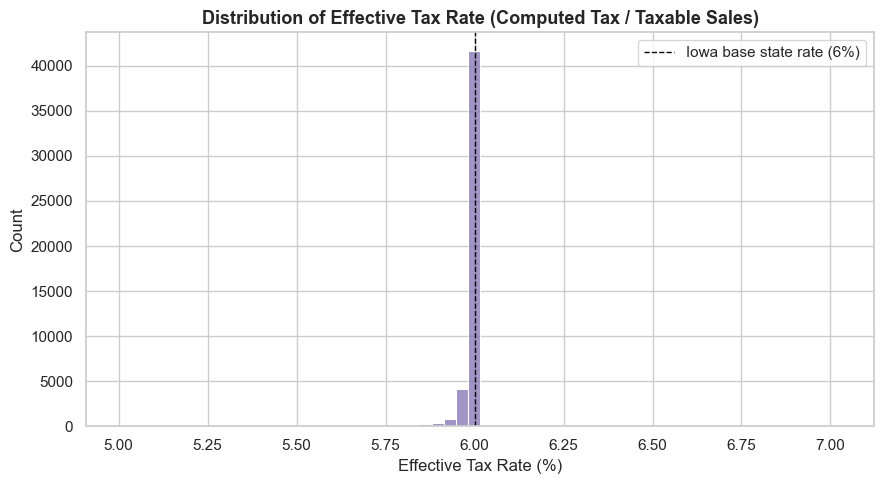

In [53]:
fig, ax = plt.subplots(figsize=(9, 5))
sns.histplot(df['effective_tax_rate'].dropna()*100, bins=60, color='#8172B2', ax=ax)
ax.set_title('Distribution of Effective Tax Rate (Computed Tax / Taxable Sales)')
ax.set_xlabel('Effective Tax Rate (%)')
ax.axvline(6.0, color='black', linestyle='--', linewidth=1, label='Iowa base state rate (6%)')
ax.legend()
plt.tight_layout()
plt.show()

In [54]:
print(df['effective_tax_rate'].describe().apply(lambda x: f'{x*100:.3f}%'))
print("\\n=> Rates cluster tightly around Iowa's 6% base state sales tax, with some cities showing higher")
print("   effective rates from local-option sales taxes layered on top.")

count    4802600.000%
mean           5.988%
std            0.055%
min            5.010%
25%            5.995%
50%            6.000%
75%            6.000%
max            7.022%
Name: effective_tax_rate, dtype: str
\n=> Rates cluster tightly around Iowa's 6% base state sales tax, with some cities showing higher
   effective rates from local-option sales taxes layered on top.


In [55]:
county_year = df.groupby(['county_name','county_type','calendar_year'])['taxable_sales'].sum().reset_index()
county_year = county_year.sort_values(['county_name','calendar_year'])
county_year['yoy_growth'] = county_year.groupby('county_name')['taxable_sales'].pct_change()

In [56]:
growth_by_type = county_year.groupby(['calendar_year','county_type'])['yoy_growth'].median().reset_index()
growth_by_type = growth_by_type[(growth_by_type.calendar_year > 2012) & (growth_by_type.calendar_year < 2026)]

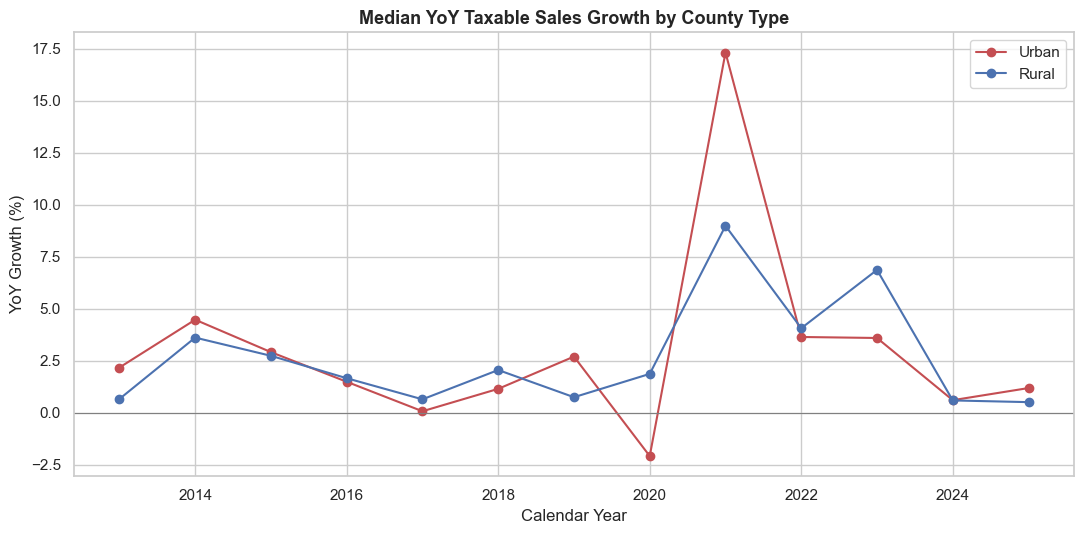

In [57]:
fig, ax = plt.subplots(figsize=(11, 5.5))
for ctype, color in [('Urban','#C44E52'), ('Rural','#4C72B0')]:
    sub = growth_by_type[growth_by_type.county_type==ctype]
    ax.plot(sub['calendar_year'], sub['yoy_growth']*100, marker='o', label=ctype, color=color)
ax.axhline(0, color='gray', linewidth=0.8)
ax.set_title('Median YoY Taxable Sales Growth by County Type')
ax.set_xlabel('Calendar Year')
ax.set_ylabel('YoY Growth (%)')
ax.legend()
plt.tight_layout()
plt.show()

The 2020 dip and 2021 rebound visible in both series line up with COVID-19 pandemic disruption to retail activity, followed by a stimulus- and reopening-driven recovery.